<a href="https://www.kaggle.com/code/lalit7881/llm-cost-performance-rankings?scriptVersionId=300910984" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/dhrubangtalukdar/global-llm-benchmark-dataset-20242026/global_llm_benchmark_dataset_models.csv


## Import dataset

In [2]:
df = pd.read_csv("/kaggle/input/datasets/dhrubangtalukdar/global-llm-benchmark-dataset-20242026/global_llm_benchmark_dataset_models.csv")

In [3]:
df.head()

,model_name,provider,release_date,context_window,api_input_cost_per_1k_usd,api_output_cost_per_1k_usd,open_source,mmlu_score,gsm8k_score,humaneval_score
0,GPT-4o,OpenAI,2024-05-13,128000,0.005,0.015,False,88.7,92.0,90.2
1,GPT-4 Turbo,OpenAI,2023-11-06,128000,0.010,0.030,False,86.5,89.0,85.4
2,GPT-3.5 Turbo,OpenAI,2023-03-01,16000,0.001,0.002,False,70.0,57.1,48.1
3,Claude 3 Opus,Anthropic,2024-03-04,200000,0.015,0.075,False,86.8,95.0,84.9
4,Claude 3 Sonnet,Anthropic,2024-03-04,200000,0.003,0.015,False,82.0,92.3,78.5


In [4]:
df.tail()

,model_name,provider,release_date,context_window,api_input_cost_per_1k_usd,api_output_cost_per_1k_usd,open_source,mmlu_score,gsm8k_score,humaneval_score
32,OpenModel-16B,Various,2024-01-01,8192,0.0,0.0,True,68.0,59.6,51.2
33,OpenModel-17B,Various,2024-01-01,8192,0.0,0.0,True,68.5,60.2,51.9
34,OpenModel-18B,Various,2024-01-01,8192,0.0,0.0,True,69.0,60.8,52.6
35,OpenModel-19B,Various,2024-01-01,8192,0.0,0.0,True,69.5,61.4,53.3
36,OpenModel-20B,Various,2024-01-01,8192,0.0,0.0,True,70.0,62.0,54.0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37 entries, 0 to 36
Data columns (total 10 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   model_name                  37 non-null     object 
 1   provider                    37 non-null     object 
 2   release_date                37 non-null     object 
 3   context_window              37 non-null     int64  
 4   api_input_cost_per_1k_usd   37 non-null     float64
 5   api_output_cost_per_1k_usd  37 non-null     float64
 6   open_source                 37 non-null     bool   
 7   mmlu_score                  37 non-null     float64
 8   gsm8k_score                 37 non-null     float64
 9   humaneval_score             37 non-null     float64
dtypes: bool(1), float64(5), int64(1), object(3)
memory usage: 2.8+ KB


In [6]:
df.describe()

,context_window,api_input_cost_per_1k_usd,api_output_cost_per_1k_usd,mmlu_score,gsm8k_score,humaneval_score
count,37.000000,37.000000,37.000000,37.000000,37.000000,37.000000
mean,66165.621622,0.001791,0.006493,71.729730,68.372973,56.583784
std,169103.859640,0.003769,0.014902,8.619708,15.981129,15.517222
min,4096.000000,0.000000,0.000000,60.500000,50.600000,29.900000
25%,8192.000000,0.000000,0.000000,65.000000,55.400000,45.600000
50%,8192.000000,0.000000,0.000000,69.000000,60.200000,51.200000
75%,32000.000000,0.001000,0.002000,79.800000,86.500000,66.000000
max,1000000.000000,0.015000,0.075000,88.700000,95.000000,90.200000


In [7]:
df.isnull().sum()

model_name                    0
provider                      0
release_date                  0
context_window                0
api_input_cost_per_1k_usd     0
api_output_cost_per_1k_usd    0
open_source                   0
mmlu_score                    0
gsm8k_score                   0
humaneval_score               0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.dtypes

model_name                     object
provider                       object
release_date                   object
context_window                  int64
api_input_cost_per_1k_usd     float64
api_output_cost_per_1k_usd    float64
open_source                      bool
mmlu_score                    float64
gsm8k_score                   float64
humaneval_score               float64
dtype: object

In [10]:
df.shape

(37, 10)

In [11]:
df.columns

Index(['model_name', 'provider', 'release_date', 'context_window',
       'api_input_cost_per_1k_usd', 'api_output_cost_per_1k_usd',
       'open_source', 'mmlu_score', 'gsm8k_score', 'humaneval_score'],
      dtype='object')

In [12]:
df.nunique()

model_name                    37
provider                      10
release_date                  15
context_window                 8
api_input_cost_per_1k_usd     11
api_output_cost_per_1k_usd    10
open_source                    2
mmlu_score                    35
gsm8k_score                   36
humaneval_score               36
dtype: int64

## Data visualizations

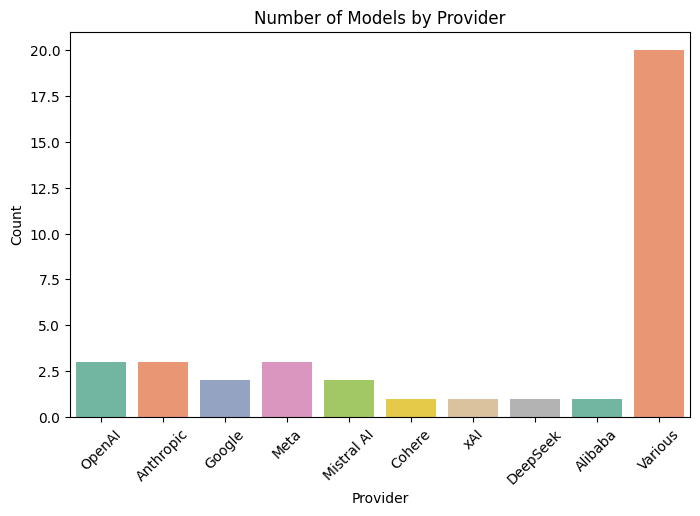

In [13]:
plt.figure(figsize=(8,5))
sns.countplot(x='provider', data=df, palette='Set2')
plt.title("Number of Models by Provider")
plt.xlabel("Provider")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

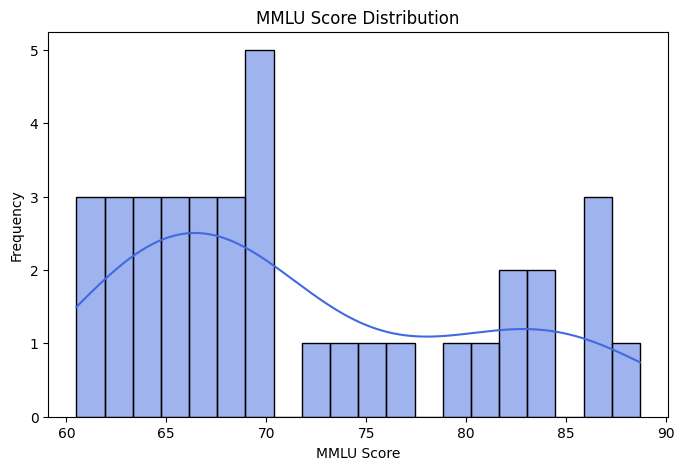

In [14]:
plt.figure(figsize=(8,5))
sns.histplot(df['mmlu_score'], bins=20, kde=True, color='royalblue')
plt.title("MMLU Score Distribution")
plt.xlabel("MMLU Score")
plt.ylabel("Frequency")
plt.show()

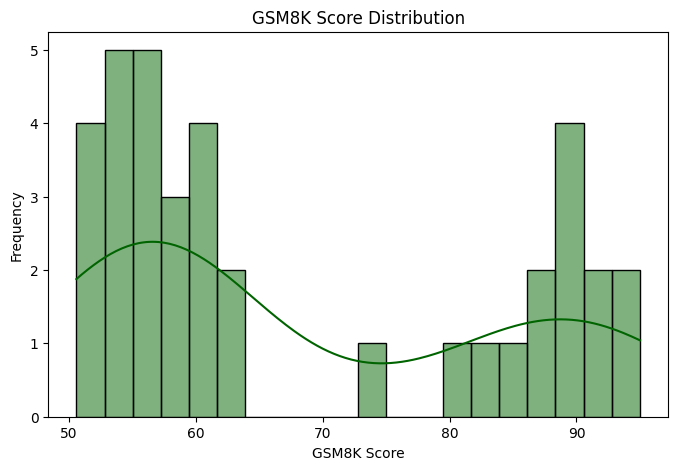

In [15]:
plt.figure(figsize=(8,5))
sns.histplot(df['gsm8k_score'], bins=20, kde=True, color='darkgreen')
plt.title("GSM8K Score Distribution")
plt.xlabel("GSM8K Score")
plt.ylabel("Frequency")
plt.show()

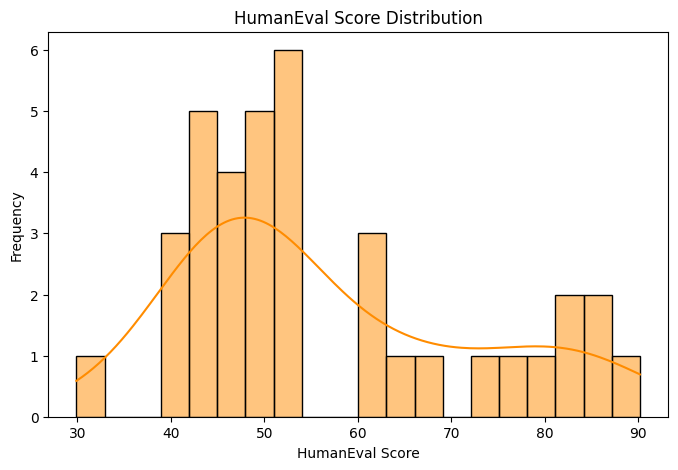

In [16]:
plt.figure(figsize=(8,5))
sns.histplot(df['humaneval_score'], bins=20, kde=True, color='darkorange')
plt.title("HumanEval Score Distribution")
plt.xlabel("HumanEval Score")
plt.ylabel("Frequency")
plt.show()

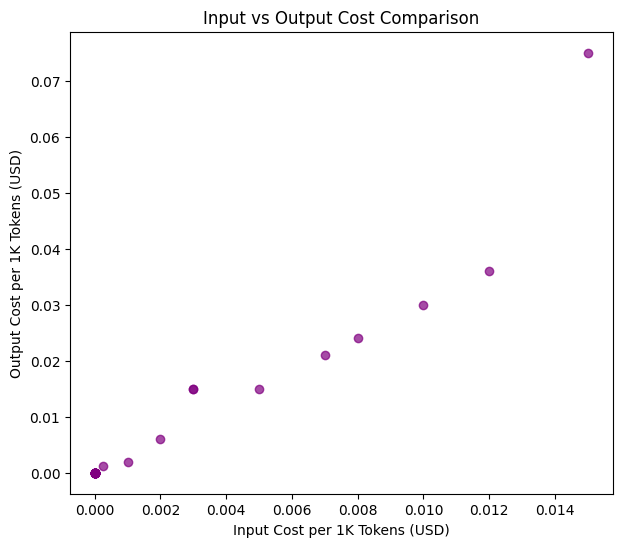

In [17]:
plt.figure(figsize=(7,6))
plt.scatter(df['api_input_cost_per_1k_usd'],
            df['api_output_cost_per_1k_usd'],
            color='purple', alpha=0.7)

plt.xlabel("Input Cost per 1K Tokens (USD)")
plt.ylabel("Output Cost per 1K Tokens (USD)")
plt.title("Input vs Output Cost Comparison")
plt.show()

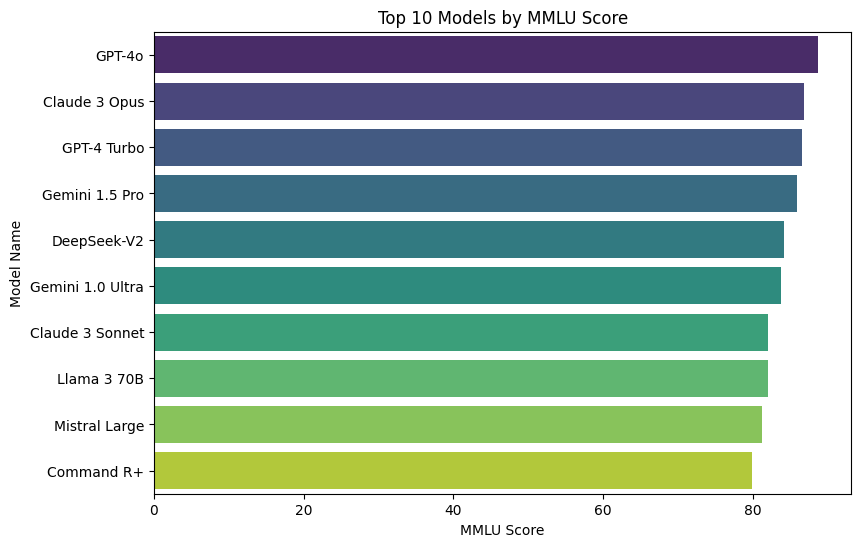

In [18]:
top_mmlu = df.sort_values(by='mmlu_score', ascending=False).head(10)

plt.figure(figsize=(9,6))
sns.barplot(x='mmlu_score', y='model_name', data=top_mmlu, palette='viridis')
plt.title("Top 10 Models by MMLU Score")
plt.xlabel("MMLU Score")
plt.ylabel("Model Name")
plt.show()

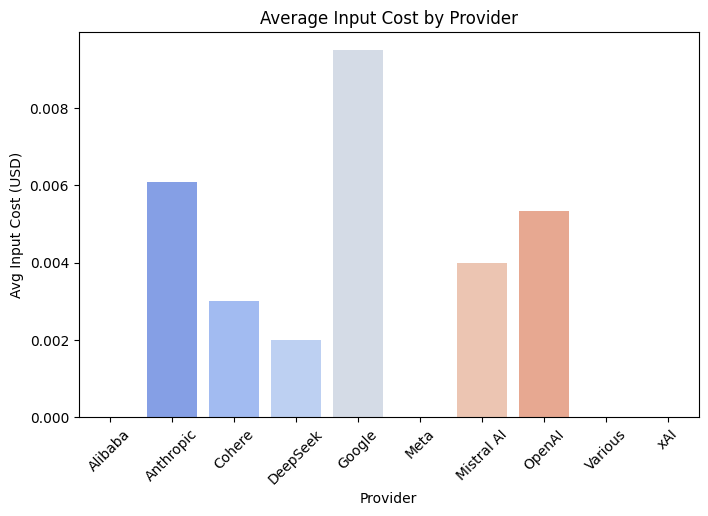

In [19]:
provider_cost = df.groupby('provider')[['api_input_cost_per_1k_usd']].mean().reset_index()

plt.figure(figsize=(8,5))
sns.barplot(x='provider', y='api_input_cost_per_1k_usd',
            data=provider_cost, palette='coolwarm')

plt.title("Average Input Cost by Provider")
plt.xlabel("Provider")
plt.ylabel("Avg Input Cost (USD)")
plt.xticks(rotation=45)
plt.show()

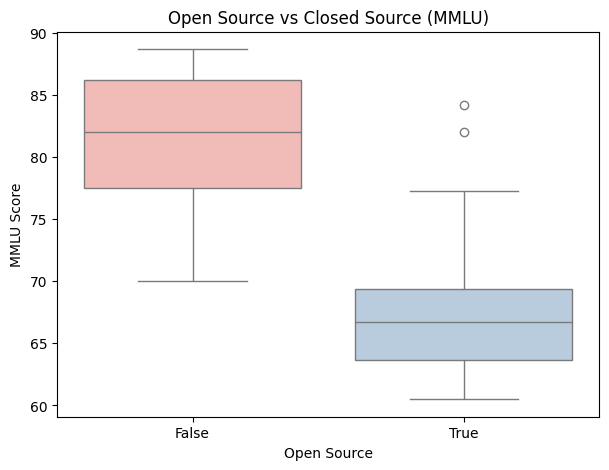

In [20]:
plt.figure(figsize=(7,5))
sns.boxplot(x='open_source', y='mmlu_score',
            data=df, palette='Pastel1')

plt.title("Open Source vs Closed Source (MMLU)")
plt.xlabel("Open Source")
plt.ylabel("MMLU Score")
plt.show()

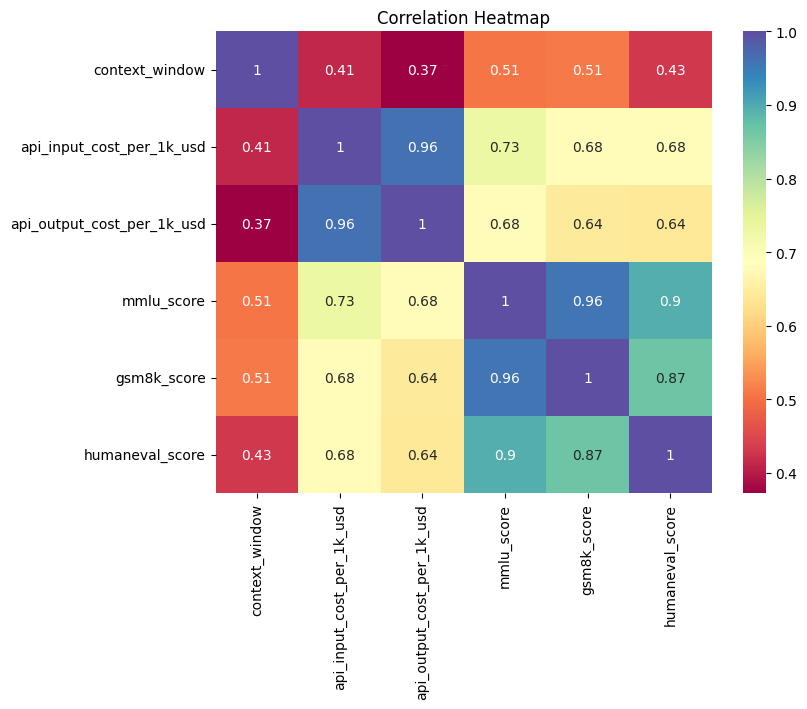

In [21]:
plt.figure(figsize=(8,6))

numeric_cols = df[['context_window',
                   'api_input_cost_per_1k_usd',
                   'api_output_cost_per_1k_usd',
                   'mmlu_score',
                   'gsm8k_score',
                   'humaneval_score']]

sns.heatmap(numeric_cols.corr(),
            annot=True,
            cmap='Spectral')

plt.title("Correlation Heatmap")
plt.show()

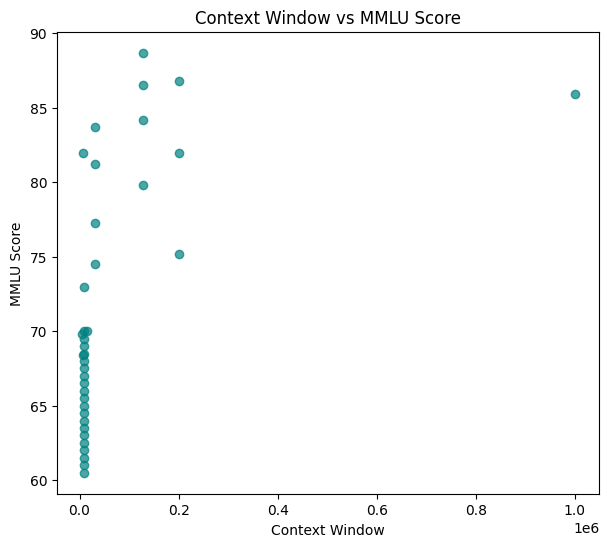

In [22]:
plt.figure(figsize=(7,6))

plt.scatter(df['context_window'],
            df['mmlu_score'],
            color='teal',
            alpha=0.7)

plt.xlabel("Context Window")
plt.ylabel("MMLU Score")
plt.title("Context Window vs MMLU Score")
plt.show()

## Feature engg

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, roc_auc_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier

In [24]:
# Create binary target based on median MMLU score
median_score = df["mmlu_score"].median()

df["performance_class"] = np.where(df["mmlu_score"] >= median_score, 1, 0)

In [25]:
df_model = df.drop(columns=["model_name", "release_date"])

In [26]:
le = LabelEncoder()

for col in df_model.select_dtypes(include="object").columns:
    df_model[col] = le.fit_transform(df_model[col])

In [27]:
X = df_model.drop("performance_class", axis=1)
y = df_model["performance_class"]

In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [29]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Model: Logistic Regression
Accuracy: 87.50%

Classification Report:
              precision    recall  f1-score   support

           0       0.80      1.00      0.89         4
           1       1.00      0.75      0.86         4

    accuracy                           0.88         8
   macro avg       0.90      0.88      0.87         8
weighted avg       0.90      0.88      0.87         8



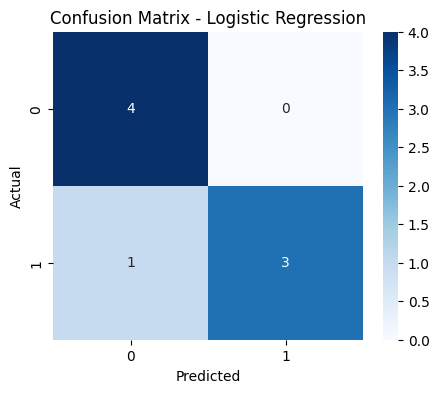

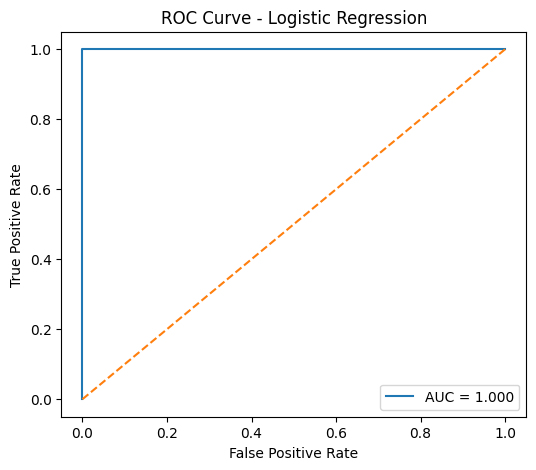

Model: Random Forest
Accuracy: 100.00%

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         4
           1       1.00      1.00      1.00         4

    accuracy                           1.00         8
   macro avg       1.00      1.00      1.00         8
weighted avg       1.00      1.00      1.00         8



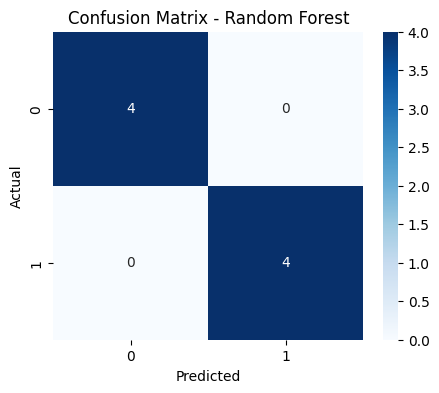

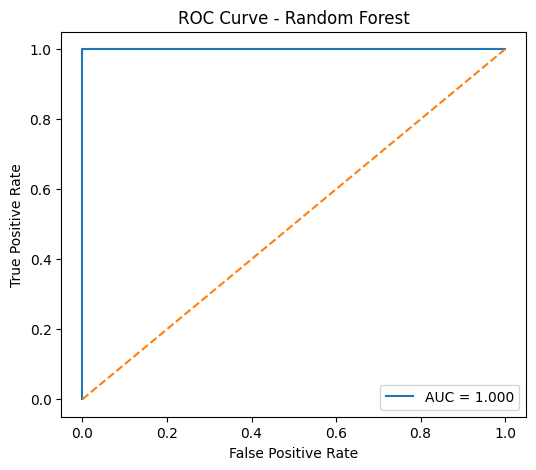

Model: Decision Tree
Accuracy: 100.00%

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         4
           1       1.00      1.00      1.00         4

    accuracy                           1.00         8
   macro avg       1.00      1.00      1.00         8
weighted avg       1.00      1.00      1.00         8



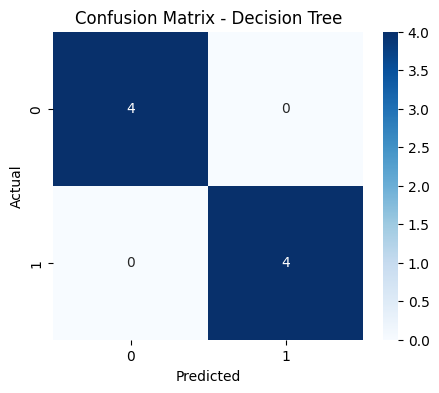

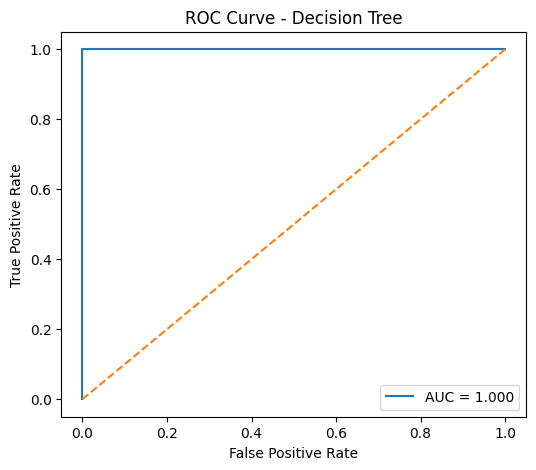

Model: SVM
Accuracy: 87.50%

Classification Report:
              precision    recall  f1-score   support

           0       0.80      1.00      0.89         4
           1       1.00      0.75      0.86         4

    accuracy                           0.88         8
   macro avg       0.90      0.88      0.87         8
weighted avg       0.90      0.88      0.87         8



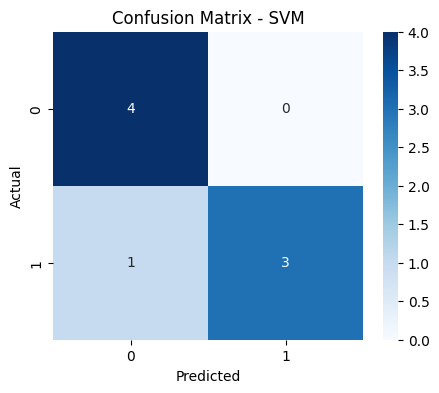

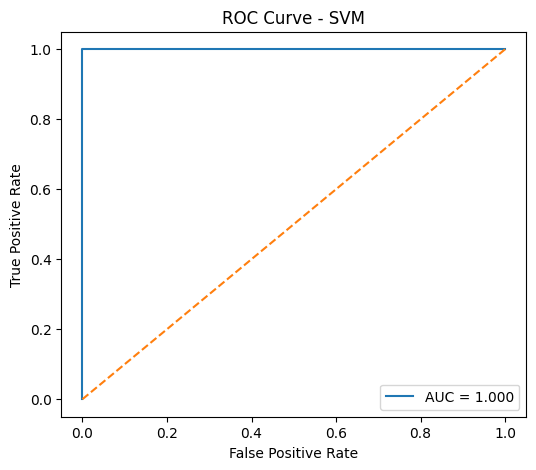

Model: Naive Bayes
Accuracy: 87.50%

Classification Report:
              precision    recall  f1-score   support

           0       0.80      1.00      0.89         4
           1       1.00      0.75      0.86         4

    accuracy                           0.88         8
   macro avg       0.90      0.88      0.87         8
weighted avg       0.90      0.88      0.87         8



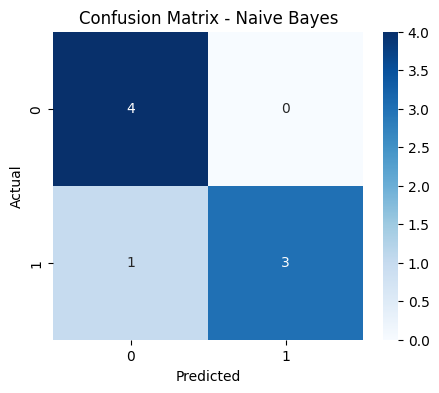

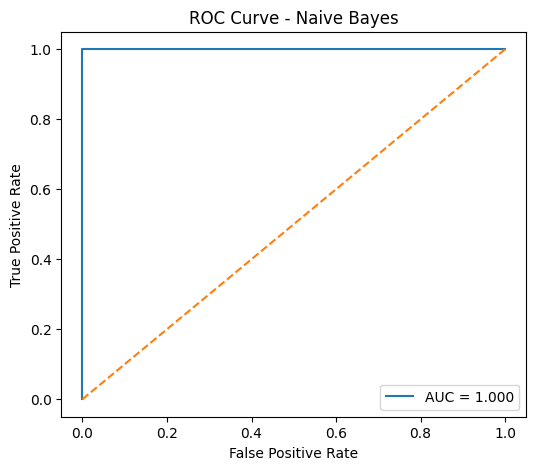

Model: KNN
Accuracy: 75.00%

Classification Report:
              precision    recall  f1-score   support

           0       0.67      1.00      0.80         4
           1       1.00      0.50      0.67         4

    accuracy                           0.75         8
   macro avg       0.83      0.75      0.73         8
weighted avg       0.83      0.75      0.73         8



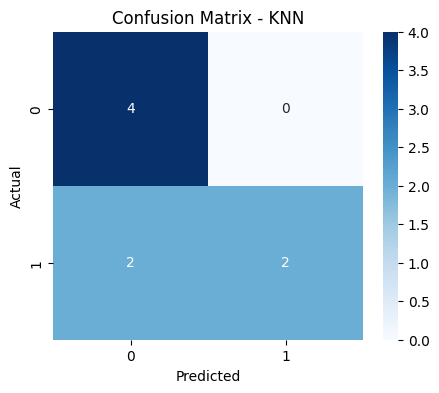

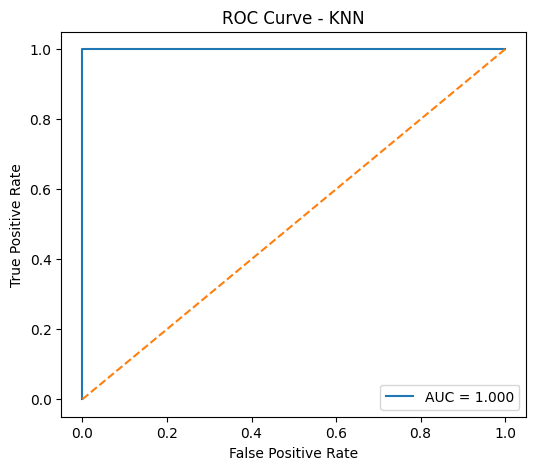

In [30]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "SVM": SVC(probability=True),
    "Naive Bayes": GaussianNB(),
    "KNN": KNeighborsClassifier()
}

for name, model in models.items():
    
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]
    
    acc = accuracy_score(y_test, y_pred) * 100
    
    print("="*50)
    print(f"Model: {name}")
    print(f"Accuracy: {acc:.2f}%")
    
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))
    
    # 🔹 Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()
    
    # 🔹 ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_score = roc_auc_score(y_test, y_prob)
    
    plt.figure(figsize=(6,5))
    plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")
    plt.plot([0,1],[0,1],'--')
    plt.title(f"ROC Curve - {name}")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.show()

## Thank you..pls upvote!!!!!!!